# Week 4 - Day 2

# Core Supervised Learning — Preprocessing, Models & Evaluation
## Scenario
Using the same Adult dataset and hold-out test from Day 1, build your first real supervised models with solid preprocessing.
Focus areas: repeatable pipelines (no data leakage), correct preprocessing for mixed data (categorical + numeric), and comparing simple classifiers to pick candidates for improvement.

### Task 1: Preprocessing Plan & Implementation
- List your numeric and categorical features explicitly. Replace '?' with NaN if not already done.
- Build a sklearn ColumnTransformer pipeline:
    - Numeric pipeline: SimpleImputer (median) → StandardScaler
    - Categorical pipeline: SimpleImputer (most_frequent / "Missing") → OneHotEncoder(handle_unknown='ignore')
- In comments, explain why you chose median imputation + OneHotEncoder — and note alternatives you considered but skipped.


### Task 2: Train Two Supervised Models (in Pipelines)
Build preprocessing + estimator pipelines for:
1.	Logistic Regression — set random_state, use a solver that supports regularization
2.	Decision Tree Classifier — set random_state
   - Fit both on the training set only.  Do not touch the hold-out test set here.

### Task 3: Evaluate on Hold-Out Test (Multiple Metrics)
- For each model, compute: accuracy, precision, recall, F1, ROC AUC, PR AUC. Build a clear comparison table including your Day 1 baseline.
- Plot ROC curves and Precision–Recall curves for both models.
- Build confusion matrices for both — which error type is more common (false positives vs false negatives), and how does that affect your chosen metric/decision?

### Task 4: Interpretability Check
- Logistic Regression:
    - Map coefficients back to feature names (use get_feature_names_out for one-hot columns).
    - List the top 10 positive and top 10 negative coefficients with a short interpretation of each.
- Decision Tree:
    - Report tree depth and train vs. test score (to check for overfitting).
    - Print/export the top 3 splits. Comment on whether the tree's logic seems sensible.

### Task 5: Write-Up & Model Selection for Day 3
- Write 1–2 paragraphs justifying which model(s) you'll develop further (e.g., logistic for interpretability, tree for nonlinearity) — back this up with your metrics.
- Save your preprocessing pipeline code for reuse. Note any preprocessing changes you plan to test tomorrow.


### Deliverable
- A Jupyter notebook
- A 1–2 page write-up comparing preprocessing choices and model metrics, stating which model(s) you're continuing with



### Import Libraries 

In [1]:
# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import fetch_openml

# Train/Test Split
from sklearn.model_selection import train_test_split

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# average_precision_score computes PR_AUC

# For Baseline Models
from sklearn.dummy import DummyClassifier

# Notebook Settings
pd.set_option("display.max_columns", None) # display all cols

sns.set_style("whitegrid") # clean white bkgrd for plots

## Problem Definition

### Business Objective

The objective is to identify individuals who are likely to earn >50K per year. A company could use this prediction to target premium products or marketing campaigns toward higher-income customers while minimizing unnecessary outreach.

### Target Variable

- Positive Class (1): Income >50K
- Negative Class (0): Income ≤50K

### Primary Evaluation Metric

Precision is selected as the primary evaluation metric because contacting individuals incurs cost. A higher precision means that a larger proportion of contacted individuals actually belong to the high-income group, reducing wasted marketing resources.

Although recall is also important, maximizing precision is more appropriate for this business scenario where false positives are more costly than missing some potential customers.

### Explanation for Non-Technical Stakeholders
We are building a model to help the marketing team identify customers who are more likely to earn over $50,000 per year. This allows the company to focus promotional campaigns on people who are more likely to respond, making better use of the marketing budget. To reduce unnecessary outreach, we prioritize making reliable positive predictions rather than contacting as many people as possible.


### Load Dataset

In [2]:
adult = fetch_openml(
    name="adult",
    version=2,
    as_frame=True
)

# version 2 is selected to make the results reproducible
# as_frame is used to get data in the form of Pandas DataFrame

df = adult.frame.copy()

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


### Dataset Information

In [3]:
# Dataset Shape

print(f"Dataset Shape: {df.shape}")
print()

# Column Information

df.info()

Dataset Shape: (48842, 15)

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB


### Preview Column Names

In [4]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'class'],
      dtype='str')

### Check Missing Values

In [5]:
# The Adult dataset stores missing values as "?" as per given task details
# Check for missing values

missing_values = df.isna().sum()

display(
    missing_values[missing_values > 0].to_frame("Missing Values")
)

,Missing Values
workclass,2799
occupation,2809
native-country,857


### Missing Value Inspection

The Adult dataset obtained from `fetch_openml()` already represents missing values as `NaN` instead of the original `"?"` symbols found in the raw UCI dataset. Missing values were identified in `workclass`, `occupation`, and `native-country`.

In [6]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 52


In [7]:
if duplicate_count > 0:
    display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10))

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
4152,17,Private,153021,12th,8,Never-married,Sales,Own-child,White,Female,0,0,20,United-States,<=50K
40948,17,Private,153021,12th,8,Never-married,Sales,Own-child,White,Female,0,0,20,United-States,<=50K
3900,18,Self-emp-inc,378036,12th,8,Never-married,Farming-fishing,Own-child,White,Male,0,0,10,United-States,<=50K
15960,18,Self-emp-inc,378036,12th,8,Never-married,Farming-fishing,Own-child,White,Male,0,0,10,United-States,<=50K
33954,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
34979,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
1668,19,Private,130431,5th-6th,3,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,36,Mexico,<=50K
19399,19,Private,130431,5th-6th,3,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,36,Mexico,<=50K
23271,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K
37599,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K


In [8]:
# Remove exact duplicate rows before splitting
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
after = df.shape[0]

print(f"Rows before: {before}")
print(f"Rows after:  {after}")
print(f"Duplicates removed: {before - after}")

Rows before: 48842
Rows after:  48790
Duplicates removed: 52


### Convert Target to Binary

In [9]:
# first, see existing lables
df["class"].value_counts()

class
<=50K    37109
>50K     11681
Name: count, dtype: int64

In [10]:
# convert them to binary
df["class"] = (
    df["class"].map({
    "<=50K": 0,
    ">50K": 1
})
.astype(int)
)

df["class"].value_counts()

class
0    37109
1    11681
Name: count, dtype: int64

### Base Rate

In [11]:
# compute the class base rate
class_counts = df["class"].value_counts().sort_index()

class_percentages = (
    df["class"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

base_rate = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages.round(2)
})

base_rate

,Count,Percentage
class,,
0,37109,76.06
1,11681,23.94


### Numeric Summary

### Interpretation

The positive class (>50K) represents **23.93%** of the dataset, while **76.07%** of individuals belong to the negative class (≤50K). This indicates that the dataset is moderately imbalanced, making evaluation metrics such as Precision and F1-score more informative than accuracy alone.

In [12]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,class
count,48790.000000,4.879000e+04,48790.000000,48790.000000,48790.000000,48790.000000,48790.000000
mean,38.652798,1.896690e+05,10.078807,1080.217688,87.595573,40.425886,0.239414
std,13.708493,1.056172e+05,2.570046,7455.905921,403.209129,12.392729,0.426730
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,1.175550e+05,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,1.781385e+05,10.000000,0.000000,0.000000,40.000000,0.000000
75%,48.000000,2.376062e+05,12.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000,1.000000


### Categorical Summary

In [13]:
df.describe(include="category")

,workclass,education,marital-status,occupation,relationship,race,sex,native-country
count,45995,48790,48790,45985,48790,48790,48790,47934
unique,8,16,7,14,6,5,2,41
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States
freq,33860,15770,22366,6165,19703,41714,32614,43792


### Value Counts

In [14]:
categorical_columns = df.select_dtypes(include="category").columns

for column in categorical_columns:
    print("="*60)
    print(f"Value Counts for '{column}'")
    display(df[column].value_counts().to_frame("Count"))
    print()

Value Counts for 'workclass'


,Count
workclass,
Private,33860
Self-emp-not-inc,3861
Local-gov,3136
State-gov,1981
Self-emp-inc,1694
Federal-gov,1432
Without-pay,21
Never-worked,10



Value Counts for 'education'


,Count
education,
HS-grad,15770
Some-college,10863
Bachelors,8013
Masters,2656
Assoc-voc,2060
11th,1812
Assoc-acdm,1601
10th,1389
7th-8th,954



Value Counts for 'marital-status'


,Count
marital-status,
Married-civ-spouse,22366
Never-married,16082
Divorced,6630
Separated,1530
Widowed,1518
Married-spouse-absent,627
Married-AF-spouse,37



Value Counts for 'occupation'


,Count
occupation,
Prof-specialty,6165
Craft-repair,6102
Exec-managerial,6082
Adm-clerical,5606
Sales,5501
Other-service,4919
Machine-op-inspct,3017
Transport-moving,2355
Handlers-cleaners,2071



Value Counts for 'relationship'


,Count
relationship,
Husband,19703
Not-in-family,12557
Own-child,7569
Unmarried,5124
Wife,2331
Other-relative,1506



Value Counts for 'race'


,Count
race,
White,41714
Black,4683
Asian-Pac-Islander,1517
Amer-Indian-Eskimo,470
Other,406



Value Counts for 'sex'


,Count
sex,
Male,32614
Female,16176



Value Counts for 'native-country'


,Count
native-country,
United-States,43792
Mexico,943
Philippines,294
Germany,206
Puerto-Rico,184
Canada,182
El-Salvador,155
India,151
Cuba,138


**Observation:**

- The majority of individuals have no capital gain, so only non-zero values are visualized.
- Among individuals with positive capital gains, the distribution is highly right-skewed, with most values clustered at lower gains and a few extremely large values.
- This suggests that `capital-gain` contains significant outliers and may benefit from transformation (e.g., log transformation) or special handling before model training.

# Create Reproducible Data Splits

To evaluate a machine learning model fairly, the dataset is divided into separate subsets. The training set is used to learn patterns from the data, while the hold-out test set is kept completely unseen until the final evaluation. This ensures that the reported performance reflects how well the model generalizes to new, unseen data.

### Separate Features and Target

In [15]:
# Features (Independent Variables)
X = df.drop(columns="class")

# Target (Dependent Variable)
y = df["class"]

### Create Appropriate Data Splits

In [16]:
# Step 1: Create the 20% hold-out test set
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# test_size is used to create a test or hold_out split, here 20 % of the data-> 0.20
# we have used stratified sampling and therefore, startify= y for fair evaluation across test and train splits
# we fixed a random state using random_state so that everyone gets the same split everytime thus making this notebook reproducible

# Step 2: Split the remaining 80% into 70% train and 10% development
X_train, X_dev, y_train, y_dev = train_test_split(
    X_train,
    y_train,
    test_size=0.125,
    stratify=y_train,
    random_state=42
)

### Verify Split Sizes

In [17]:
print("Dataset Split Sizes")
print("-" * 30)

print(f"Training Set      : {X_train.shape[0]} samples")
print(f"Development Set   : {X_dev.shape[0]} samples")
print(f"Hold-Out Test Set : {X_test.shape[0]} samples")

Dataset Split Sizes
------------------------------
Training Set      : 34153 samples
Development Set   : 4879 samples
Hold-Out Test Set : 9758 samples


### Verify Stratification

In [18]:
train_distribution = (
    y_train
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

dev_distribution = (
    y_dev
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

test_distribution = (
    y_test
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

comparison = pd.DataFrame({
    "Training (%)": train_distribution.round(2),
    "Development (%)": dev_distribution.round(2),
    "Testing (%)": test_distribution.round(2)
})

comparison.index = ["<=50K", ">50K"]

comparison

,Training (%),Development (%),Testing (%)
<=50K,76.06,76.06,76.06
>50K,23.94,23.94,23.94


## Why is a Hold-Out Test Set Necessary?

A hold-out test set provides an unbiased estimate of how well a machine learning model performs on unseen data. It is kept completely separate during model development and is only used after the final model has been selected.

Using the hold-out test set during hyperparameter tuning introduces **test set leakage**, a form of data leakage where information from the test set indirectly influences model selection. This leads to overly optimistic performance estimates and reduces confidence that the model will generalize well to new, unseen data.

# Baseline Models (From Day 1)

Before training complex machine learning models, simple baseline models are created to establish a minimum performance benchmark. Any future machine learning model should outperform these baselines to demonstrate that it has learned meaningful patterns from the data.

### Majority Class Predictor

In [19]:
# Create the majority-class baseline model
majority_baseline = DummyClassifier(
    strategy="most_frequent"
)

# Train the model
majority_baseline.fit(X_train, y_train)

# Make predictions on the hold-out test set
y_pred_majority = majority_baseline.predict(X_test)

### Evaluate the Baseline

In [20]:
majority_results = {
    "Accuracy": accuracy_score(y_test, y_pred_majority),
    "Precision": precision_score(y_test, y_pred_majority, zero_division=0),
    "Recall": recall_score(y_test, y_pred_majority, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_majority, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, y_pred_majority),
    "PR AUC": average_precision_score(y_test, y_pred_majority)
}

# zero division is done so that if anywhere during calculations, there comes a result for 0/0, simply take it as 0

pd.DataFrame(
    majority_results,
    index=["Majority Baseline"]
).round(3)

,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
Majority Baseline,0.761,0.0,0.0,0.0,0.5,0.239


### Confusion Matrix

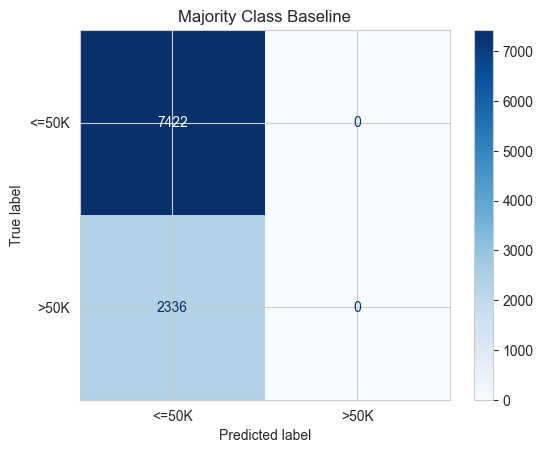

In [21]:
cm = confusion_matrix(
    y_test,
    y_pred_majority
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["<=50K", ">50K"]
)

disp.plot(cmap="Blues")

plt.title("Majority Class Baseline")
plt.show()

### Rule-Based Classifier

In [22]:
# Predict >50K if capital-gain > 0

y_pred_rule = (
    X_test["capital-gain"] > 0
).astype(int)

### Evaluate

In [23]:
rule_results = {
    "Accuracy": accuracy_score(y_test, y_pred_rule),
    "Precision": precision_score(y_test, y_pred_rule, zero_division=0),
    "Recall": recall_score(y_test, y_pred_rule, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_rule, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, y_pred_rule),
    "PR AUC": average_precision_score(y_test, y_pred_rule)
}

pd.DataFrame(
    rule_results,
    index=["Rule-Based Baseline"]
).round(3)

,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
Rule-Based Baseline,0.779,0.608,0.215,0.318,0.586,0.319


### Confusion Matrix

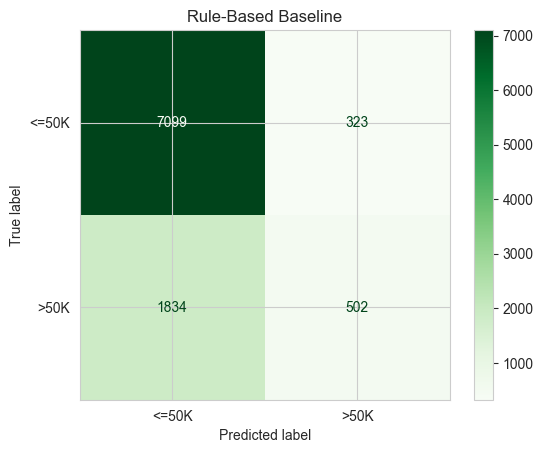

In [24]:
cm = confusion_matrix(
    y_test,
    y_pred_rule
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["<=50K", ">50K"]
)

disp.plot(cmap="Greens")

plt.title("Rule-Based Baseline")

plt.show()

### Final Comparison Table

In [25]:
comparison = pd.DataFrame([
    majority_results,
    rule_results
], index=[
    "Majority Baseline",
    "Rule-Based Baseline"
])

comparison.round(3)

,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
Majority Baseline,0.761,0.000,0.000,0.000,0.500,0.239
Rule-Based Baseline,0.779,0.608,0.215,0.318,0.586,0.319


### Baseline Model Interpretation

The rule-based classifier outperformed the majority-class baseline across all evaluation metrics. While the majority baseline achieved 76.1% accuracy, it failed to identify any individuals earning more than \$50K, resulting in zero precision, recall, and F1-score for the positive class.

The rule-based classifier, using `capital-gain > 0`, improved the accuracy to 78.2% and achieved a precision of 62.5%, indicating that most of its positive predictions were correct. However, its recall of 22.5% shows that many high-income individuals were still missed. Future machine learning models should aim to improve recall and F1-score while maintaining or improving precision to provide more balanced and useful predictions.

### What's the minimum improvement a real model would need to be considered "useful"?

A useful machine learning model should outperform both baselines across the primary evaluation metrics. In particular, it should achieve a higher F1-score than 0.331 while maintaining strong precision and improving recall, allowing it to identify a larger proportion of high-income individuals without generating excessive false positives.

## Data & Feature Issues Identified from Day 1

Based on yesterday's exploratory data analysis and baseline results, the following observations guide today's preprocessing and modeling steps.

1. **Missing categorical values** (`workclass`, `occupation`, `native-country`)
   → **Today's approach:** Impute missing values using **SimpleImputer (most frequent)** before model training.

2. **Numeric features**
   → **Today's approach:** Impute missing numeric values (if any) using the **median**, then apply **StandardScaler** to place numerical features on a similar scale.

3. **Categorical features cannot be used directly by machine learning models**
   → **Today's approach:** Apply **One-Hot Encoding** (`OneHotEncoder(handle_unknown="ignore")`) to convert categorical variables into numerical features.

4. **Highly skewed features** (`capital-gain`, `capital-loss`)
   → **Today's approach:** Use them as they are for the baseline models. More advanced transformations (such as log transformation or binning) may be explored later.

5. **Redundant education features** (`education` and `education-num`)
   → **Today's approach:** Keep both features for now and evaluate their importance before considering feature removal.

6. **High-cardinality feature** (`native-country`)
   → **Today's approach:** Encode all categories using One-Hot Encoding. Grouping rare countries into an `"Other"` category can be investigated in future experiments.

## Primary Metric for the Week

The primary optimization metric remains Precision, since the business objective is to minimize wasted marketing outreach. F1-score and PR AUC will also be monitored to ensure improvements are balanced and not achieved by sacrificing recall excessively.

# TODAY'S TASKS

In [26]:
# Preprocessing / Model Libraries
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

## Task 1 — Feature Lists & Column Dropping Decisions

In [61]:
# ===============================================================
# Ablation Test: Is `education` redundant given `education-num`?
# ===============================================================
# Rather than dropping `education` on assumption, I test it directly:
# fit on X_train, decide using X_dev (NOT X_test — test stays untouched
# until the final Task 3 evaluation).

numeric_features_ablation = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]

categorical_with_education = [
    "workclass", "education", "marital-status", "occupation",
    "relationship", "race", "sex", "native-country"
]

categorical_without_education = [
    "workclass", "marital-status", "occupation",
    "relationship", "race", "sex", "native-country"
]

def build_preprocessor(cat_features):
    """Reusable helper so both ablation variants share identical numeric handling."""
    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ])
    return ColumnTransformer(transformers=[
        ("num", numeric_pipeline, numeric_features_ablation),
        ("cat", categorical_pipeline, cat_features)
    ])

ablation_results = {}

for label, cat_feats in [
    ("WITH education", categorical_with_education),
    ("WITHOUT education", categorical_without_education)
]:
    pre = build_preprocessor(cat_feats)
    pipe = Pipeline(steps=[
        ("preprocessor", pre),
        ("classifier", LogisticRegression(solver="liblinear", random_state=42, max_iter=1000))
    ])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_dev)                 # ← was X_test
    y_proba = pipe.predict_proba(X_dev)[:, 1]     # ← was X_test

    ablation_results[label] = {
        "Accuracy": accuracy_score(y_dev, y_pred),        # ← was y_test
        "Precision": precision_score(y_dev, y_pred, zero_division=0),
        "Recall": recall_score(y_dev, y_pred, zero_division=0),
        "F1 Score": f1_score(y_dev, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_dev, y_proba),
        "PR AUC": average_precision_score(y_dev, y_proba)
    }

ablation_df = pd.DataFrame(ablation_results).T
ablation_df.round(4)

,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
WITH education,0.8588,0.7487,0.6173,0.6767,0.9096,0.7725
WITHOUT education,0.8584,0.7477,0.6164,0.6757,0.9094,0.7719


### Ablation Conclusion

Contrary to the initial hypothesis that `education` is fully redundant with
`education-num`, the ablation test — evaluated on the **dev set** rather than
the hold-out test set, since this is a feature-selection decision and the test
set must remain untouched until final model evaluation — shows a small but
consistent cost to dropping `education`. Every metric declines without it:
Precision falls from 0.7487 to 0.7477, F1 from 0.6767 to 0.6757, and ROC AUC
and PR AUC show the same direction of decline.

**Decision: keep both `education` and `education-num`** for this iteration.
The two features are not fully substitutable despite their apparent overlap —
`education` still contributes a small, consistent amount of signal beyond
`education-num` alone. This can be re-tested if regularization strength or
feature selection is revisited later in the week.

In [28]:
# ============================================================
# Final Feature Lists (decision applied)
# ============================================================
# fnlwgt: dropped — it's a census sampling weight, not a person-level attribute, and carries no real predictive relationship with income.
# education:kept since it affects our primary metric of evaluation (precison) badly.

numeric_features = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]

categorical_features = [
    "workclass", "education", "marital-status", "occupation",
    "relationship", "race", "sex", "native-country"
]

print("Numeric Features:\n", numeric_features)
print()
print("Categorical Features:\n", categorical_features)

Numeric Features:
 ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Categorical Features:
 ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


## Note:
I have already done this step in initial cells of this notebook: '**Replace '?' with NaN if not already done.**'

## sklearn ColumnTransformer pipeline

In [29]:
# -------------------- Numeric Pipeline --------------------
# Why these choices?
# • Median imputation replaces missing numeric values and is more robust to outliers than the mean.
# • StandardScaler scales numerical features to a similar range, which helps models such as Logistic Regression learn more effectively.

# Alternatives considered:
# • Mean imputation (more sensitive to outliers)
# • KNN Imputation (more computationally expensive and unnecessary for this baseline model)

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [30]:
# ------------------ Categorical Pipeline ------------------
# Why these choices?
# • Most-frequent imputation fills missing categorical values while preserving existing categories.
# • OneHotEncoder converts categorical variables into numerical features without introducing any artificial ordering.
# • handle_unknown="ignore" prevents errors if unseen categories appear in the test or future data.

# Alternatives considered:
# • Constant-value imputation (e.g., replacing missing values with "Missing")
# • Ordinal Encoding / Label Encoding (not suitable because most categorical features are nominal, not ordered)
# • Target Encoding (powerful but can introduce data leakage if not applied carefully)

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [31]:
# Combine both pipelines
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

## Task 2 — Train Two Supervised Models (in pipelines)

In [32]:
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        solver="liblinear", random_state=42, max_iter=1000
    ))
])

# preprocessor is just what we set in the previous cell
# solver="liblinear" is an optimization algorithm suitable for binary classification problems. It also supports L1 and L2 regularization, helping reduce overfitting by preventing the model from relying too heavily on individual features.
# random_seed=42 for reproducible results : )
# max_iter increases the maximum number of training iterations, allowing the optimization algorithm enough time to converge.

tree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

# Fit on training set ONLY — hold-out test untouched here
log_reg_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [33]:
# Fit on training set ONLY — hold-out test untouched here
tree_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## Task 3 — Evaluate on Hold-Out Test (Multiple Metrics)

In [34]:
def evaluate_model(model, X_eval, y_eval):
    """Reusable evaluation function for any fitted classifier pipeline."""
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]
    results = {
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Precision": precision_score(y_eval, y_pred, zero_division=0),
        "Recall": recall_score(y_eval, y_pred, zero_division=0),
        "F1 Score": f1_score(y_eval, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_eval, y_proba),
        "PR AUC": average_precision_score(y_eval, y_proba)
    }
    return results, y_pred, y_proba

log_reg_results, log_reg_pred, log_reg_proba = evaluate_model(log_reg_pipeline, X_test, y_test)
tree_results, tree_pred, tree_proba = evaluate_model(tree_pipeline, X_test, y_test)

full_comparison = pd.DataFrame([
    majority_results, rule_results, log_reg_results, tree_results
], index=["Majority Baseline", "Rule-Based Baseline", "Logistic Regression", "Decision Tree"])

full_comparison.round(3)

,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
Majority Baseline,0.761,0.000,0.000,0.000,0.500,0.239
Rule-Based Baseline,0.779,0.608,0.215,0.318,0.586,0.319
Logistic Regression,0.850,0.728,0.593,0.654,0.902,0.756
Decision Tree,0.814,0.615,0.599,0.607,0.770,0.495


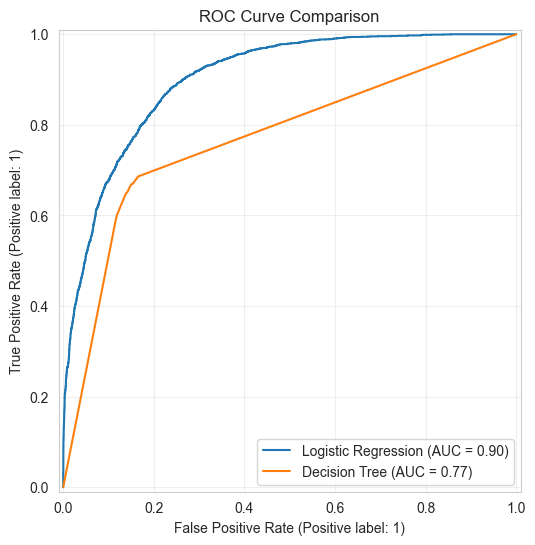

In [35]:
fig, ax = plt.subplots(figsize=(7, 6))

RocCurveDisplay.from_predictions(
    y_test,
    log_reg_proba,
    name="Logistic Regression",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_test,
    tree_proba,
    name="Decision Tree",
    ax=ax
)

ax.set_title("ROC Curve Comparison")
ax.grid(alpha=0.3)

plt.show()

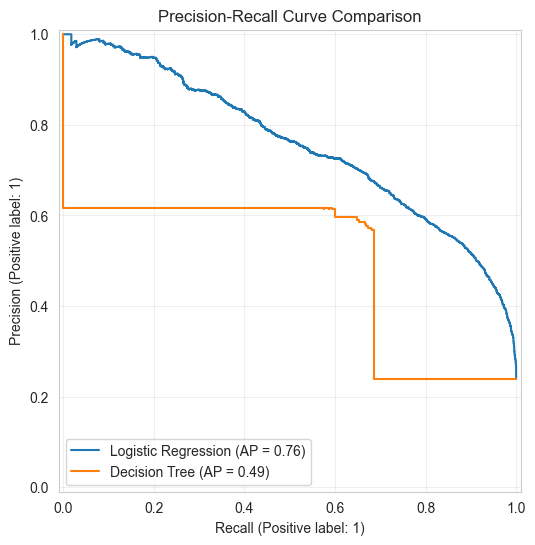

In [36]:
fig, ax = plt.subplots(figsize=(7, 6))

PrecisionRecallDisplay.from_predictions(
    y_test,
    log_reg_proba,
    name="Logistic Regression",
    ax=ax
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    tree_proba,
    name="Decision Tree",
    ax=ax
)

ax.set_title("Precision-Recall Curve Comparison")
ax.grid(alpha=0.3)

plt.show()

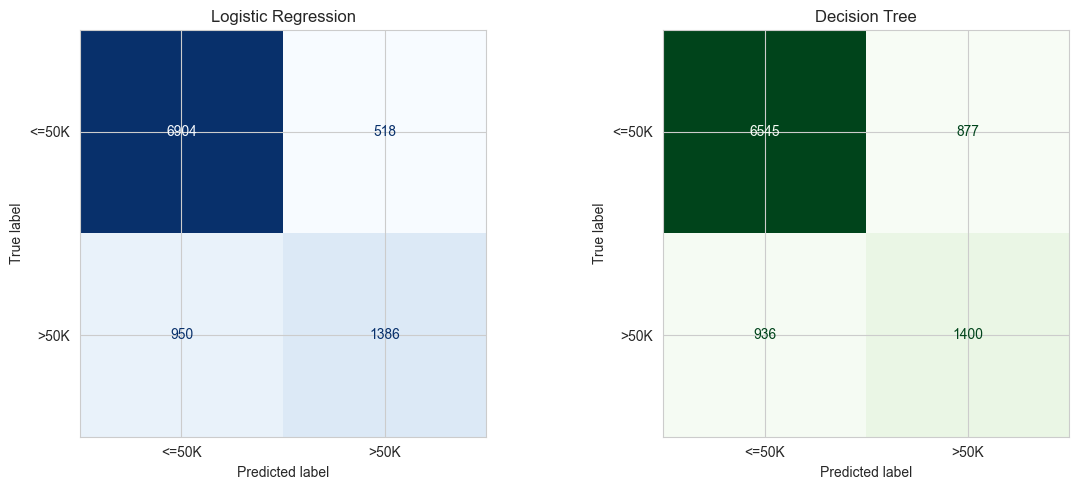

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, log_reg_pred),
    display_labels=["<=50K", ">50K"]
).plot(ax=axes[0], cmap="Blues", colorbar=False)

axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay(
    confusion_matrix(y_test, tree_pred),
    display_labels=["<=50K", ">50K"]
).plot(ax=axes[1], cmap="Greens", colorbar=False)

axes[1].set_title("Decision Tree")

plt.tight_layout()
plt.show()

### Error Type Discussion

The confusion matrices show different error patterns for the two models.

- **Logistic Regression**
  - False Positives: **518**
  - False Negatives: **950**

- **Decision Tree**
  - False Positives: **877**
  - False Negatives: **936**

Logistic Regression produces substantially fewer false positives than the Decision Tree, although it has slightly more false negatives. This results in a much higher precision (0.728 vs. 0.615), which aligns well with the project's business objective of minimizing unnecessary marketing outreach.

The Decision Tree identifies slightly more high-income individuals (slightly higher recall), but at the cost of many additional false positives. Since contacting low-income individuals wastes marketing resources, Logistic Regression provides the better trade-off and is the preferred model.

## Task 4 — Interpretability Check
### "Can we explain why our models make the predictions they do?"

### Logistic Regression

In [63]:
feature_names = log_reg_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefficients = log_reg_pipeline.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
}).sort_values("Coefficient", ascending=False)

print("Top 10 Positive Coefficients")
display(coef_df.head(10))

Top 10 Positive Coefficients


,Feature,Coefficient
2,num__capital-gain,2.481885
31,cat__marital-status_Married-civ-spouse,1.593819
30,cat__marital-status_Married-AF-spouse,1.183838
82,cat__native-country_Ireland,0.924879
39,cat__occupation_Exec-managerial,0.791797
72,cat__native-country_France,0.765909
91,cat__native-country_Philippines,0.751933
63,cat__native-country_Cambodia,0.735162
55,cat__relationship_Wife,0.707637
1,num__education-num,0.689279


In [62]:
print("Top 10 Negative Coefficients")
display(coef_df.tail(10).sort_values("Coefficient"))

Top 10 Negative Coefficients


,Feature,Coefficient
44,cat__occupation_Priv-house-serv,-1.453944
33,cat__marital-status_Never-married,-1.269110
66,cat__native-country_Columbia,-1.127529
61,cat__sex_Female,-1.049372
40,cat__occupation_Farming-fishing,-0.970612
68,cat__native-country_Dominican-Republic,-0.914370
52,cat__relationship_Other-relative,-0.899776
43,cat__occupation_Other-service,-0.884038
53,cat__relationship_Own-child,-0.857327
34,cat__marital-status_Separated,-0.833237


### Top 10 Positive Coefficients — Interpretation

| Feature | Coef | Interpretation |
|---|---|---|
| `capital-gain` | +2.482 | By far the strongest predictor — any positive capital gain (e.g. stock sale, investment income) is a very strong signal of financial means beyond salary alone. |
| `marital-status_Married-civ-spouse` | +1.594 | Married individuals in this dataset skew toward dual-income households and older, more established careers — the single strongest categorical signal. |
| `marital-status_Married-AF-spouse` | +1.184 | Married to active-duty military personnel; likely correlates with stable household income and benefits, though this is a very small category. |
| `native-country_Ireland` | +0.925 | Small sample size for this category likely inflates the coefficient — treat as a noisy estimate rather than a strong generalizable signal. |
| `occupation_Exec-managerial` | +0.792 | Executive/managerial roles are directly tied to higher salary bands — an intuitive, reliable signal. |
| `native-country_France` | +0.766 | Small-sample category; same caution as Ireland above — likely unstable rather than a robust finding. |
| `native-country_Philippines` | +0.752 | Small-sample category; coefficient magnitude should be treated cautiously rather than as a strong causal signal. |
| `native-country_Cambodia` | +0.735 | Small-sample category; same caution applies — one-hot encoding on rare groups tends to produce inflated coefficients. |
| `relationship_Wife` | +0.708 | Overlaps conceptually with `Married-civ-spouse` — reflects the same married/dual-income household pattern from a different angle of the same information. |
| `education-num` | +0.689 | More years of education is a direct, expected driver of higher income — one of the few purely numeric top-10 features. |

---

### Top 10 Negative Coefficients — Interpretation

| Feature | Coef | Interpretation |
|---|---|---|
| `occupation_Priv-house-serv` | -1.454 | Private household service work has the lowest pay ceiling in the dataset — the strongest single negative signal. |
| `marital-status_Never-married` | -1.269 | Never-married individuals skew younger and earlier in their careers, correlating with lower income. |
| `native-country_Columbia` | -1.128 | Small-sample category; likely an inflated, unstable coefficient rather than a strong generalizable signal. |
| `sex_Female` | -1.049 | Reflects a real gender income gap present in the 1994 Census data this dataset is drawn from. |
| `occupation_Farming-fishing` | -0.971 | Manual/seasonal labor sector, historically lower and less stable pay. |
| `native-country_Dominican-Republic` | -0.914 | Small-sample category; same caution as Columbia above. |
| `relationship_Other-relative` | -0.900 | Non-nuclear household role, often correlated with single-income or dependent household status. |
| `occupation_Other-service` | -0.884 | Catch-all service-sector category, generally lower-wage work. |
| `relationship_Own-child` | -0.857 | Still a dependent, not the primary household earner — expected to skew low income. |
| `marital-status_Separated` | -0.833 | Similar profile to divorced/never-married; typically single-income household. |

**Note on small-sample categories:** Several of the largest-magnitude coefficients in both tables — `native-country_Ireland`, `France`, `Philippines`, `Cambodia` (positive) and `Columbia`, `Dominican-Republic` (negative) — come from countries with very few rows in the training data. One-hot encoding rare categories tends to produce unstable, inflated coefficient estimates, since there's little data to constrain them. These should be read as noisy artifacts of small sample size rather than robust, generalizable findings — unlike `capital-gain`, `Married-civ-spouse`, `education-num`, or `sex_Female`, which are backed by large enough subgroups to be trusted.

### Decision Tree

In [39]:
tree_model = tree_pipeline.named_steps["classifier"]
print("Tree depth:", tree_model.get_depth())
print("Tree leaves:", tree_model.get_n_leaves())
print()
print("Train accuracy:", round(tree_pipeline.score(X_train, y_train), 4))
print("Test accuracy:", round(tree_pipeline.score(X_test, y_test), 4))

Tree depth: 48
Tree leaves: 5928

Train accuracy: 0.9752
Test accuracy: 0.8142


In [43]:
tree_text = export_text(tree_model, feature_names=list(feature_names), max_depth=2)
print(tree_text)

|--- cat__marital-status_Married-civ-spouse <= 0.50
|   |--- num__capital-gain <= 0.76
|   |   |--- num__education-num <= 1.34
|   |   |   |--- truncated branch of depth 29
|   |   |--- num__education-num >  1.34
|   |   |   |--- truncated branch of depth 24
|   |--- num__capital-gain >  0.76
|   |   |--- num__age <= -1.33
|   |   |   |--- truncated branch of depth 2
|   |   |--- num__age >  -1.33
|   |   |   |--- truncated branch of depth 5
|--- cat__marital-status_Married-civ-spouse >  0.50
|   |--- num__education-num <= 0.56
|   |   |--- num__capital-gain <= 0.51
|   |   |   |--- truncated branch of depth 46
|   |   |--- num__capital-gain >  0.51
|   |   |   |--- truncated branch of depth 11
|   |--- num__education-num >  0.56
|   |   |--- num__capital-gain <= 0.51
|   |   |   |--- truncated branch of depth 40
|   |   |--- num__capital-gain >  0.51
|   |   |   |--- truncated branch of depth 5



### Decision Tree Interpretation

The Decision Tree reached a depth of **48** with **5,928 leaves**, indicating a highly complex model. It achieved **97.5% training accuracy** but only **81.4% test accuracy**, suggesting that it overfits the training data.

The first three splits are based on **Married-civ-spouse**, **Capital Gain**, and **Education Level**, which are sensible predictors of income and align with the patterns observed during exploratory data analysis. Although the learned rules are intuitive, the excessive tree depth reduces the model's ability to generalize to unseen data.

### A fun little way to visualize the decision tree : )

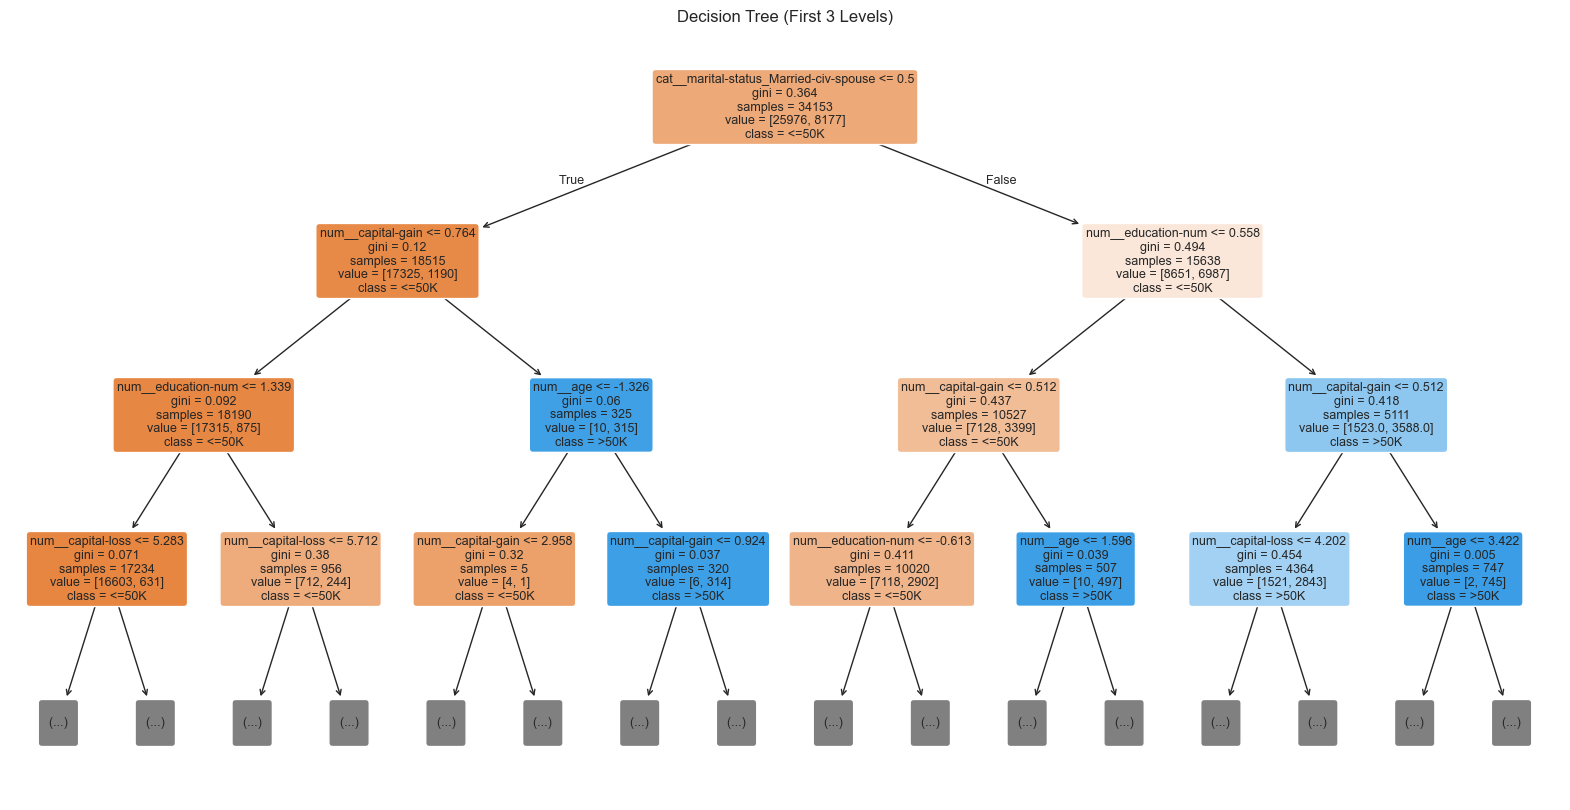

In [44]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["<=50K", ">50K"],
    filled=True,
    rounded=True,
    max_depth=3,        # show only first few levels
    fontsize=9
)

plt.title("Decision Tree (First 3 Levels)")
plt.show()

In [53]:
!pip install graphviz

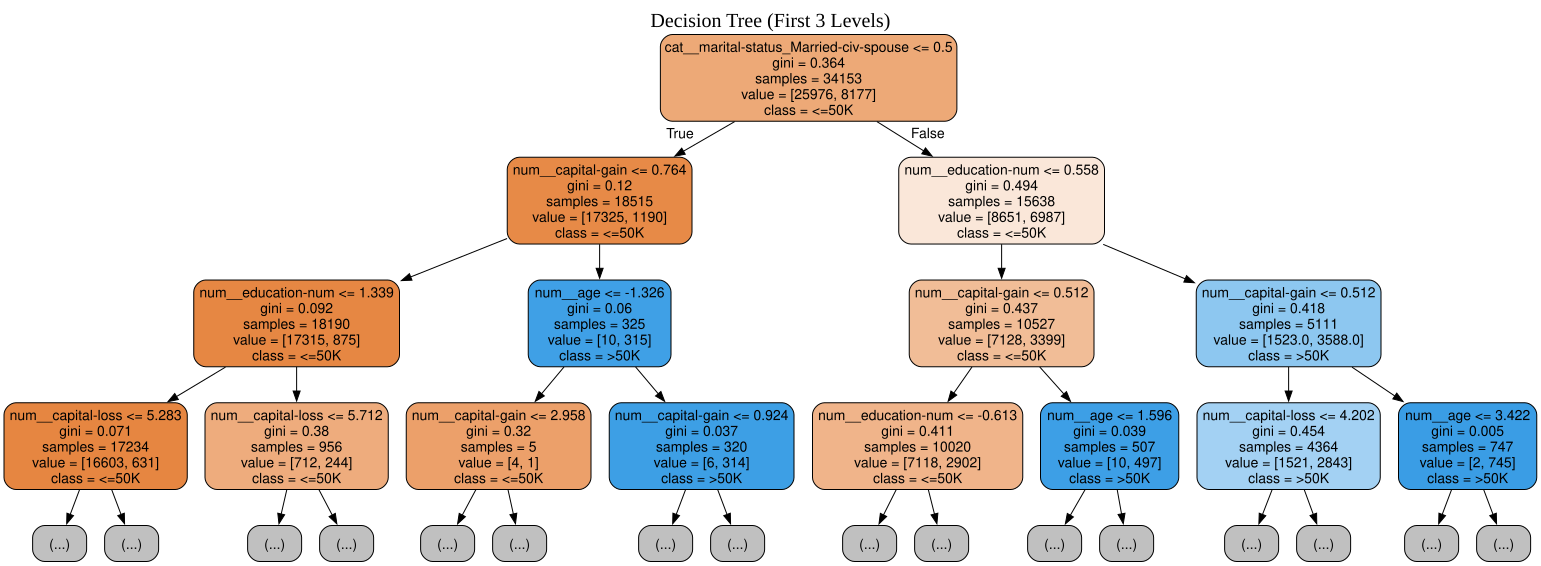

In [59]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    tree_model,
    out_file=None,
    feature_names=feature_names,
    class_names=["<=50K", ">50K"],
    filled=True,
    rounded=True,
    max_depth=3
)

# Insert graph attributes after the opening "digraph Tree {"
dot_data = dot_data.replace(
    "digraph Tree {",
    'digraph Tree {\nlabel="Decision Tree (First 3 Levels)";\nlabelloc="t";\nfontsize=20;'
)

graphviz.Source(dot_data)

## Task 5 — Write-Up & Model Selection for Day 3

### Model Selection for Day 3

Both supervised models performed substantially better than the Day 1 baselines. Logistic Regression achieved the best overall performance with an **accuracy of 85.0%**, **precision of 72.8%**, **recall of 59.3%**, **F1-score of 0.654**, **ROC AUC of 0.902**, and **PR AUC of 0.756**. In comparison, the Decision Tree achieved a similar recall (59.9%) but lower precision (61.5%), F1-score (0.607), ROC AUC (0.770), and PR AUC (0.495). Since the business objective prioritizes precision to reduce unnecessary marketing outreach, Logistic Regression is currently the stronger model.

Although the Decision Tree provides easy-to-understand decision rules, it showed clear signs of overfitting, achieving **97.5% training accuracy** but only **81.4% test accuracy**. Logistic Regression, on the other hand, produced more stable generalization while also allowing feature coefficients to be interpreted directly. For these reasons, Logistic Regression will be the primary model developed further on Day 3, while the Decision Tree may still be improved through pruning or hyperparameter tuning.

---

## Preprocessing Pipeline for Reuse

The preprocessing pipeline developed today will be reused for future experiments. It applies **median imputation** and **standardization** to numeric features, and **most-frequent imputation** followed by **One-Hot Encoding** to categorical features using a `ColumnTransformer`. Keeping preprocessing inside the pipeline ensures that all transformations are learned only from the training data, preventing data leakage and making the workflow reproducible.

---

## Planned Improvements for Day 3

The following preprocessing and modeling improvements will be explored next:

* Tune the Decision Tree (e.g., `max_depth`, `min_samples_split`, `min_samples_leaf`) to reduce overfitting.
* Experiment with Logistic Regression regularization (`C`) to improve generalization.
* Investigate transformations for the highly skewed **capital-gain** and **capital-loss** features (e.g., log transformation or binning).
* Evaluate whether keeping both **education** and **education-num** improves performance or whether one should be removed.
* Consider grouping infrequent **native-country** categories to reduce sparse one-hot encoded features.

In [60]:
import joblib
joblib.dump(preprocessor, "preprocessor_day2.pkl")

['preprocessor_day2.pkl']